# MNIST MLP Notebook for Google Colab

## What this notebook demonstrates

1. **Intro to MNIST** and quick data inspection  
2. **A custom `Dataset` class** derived from `torch.utils.data.Dataset`  
3. **Train / validation / test** data handling  
4. **`DataLoader` batches** and the minimal PyTorch training loop  
5. **A multilayer perceptron (MLP)** for digit classification  
6. **Validation monitoring** during training  
7. **Checkpoint saving and resume**  
8. **Final evaluation** on the test set  

## Colab design choices

- Uses **`torchvision.datasets.MNIST`** directly, so there are **no local helper files** to upload.
- Uses **automatic device detection**.
- Uses a **`FAST_RUN` option** by default so **Run all** finishes quickly in Colab.
- Uses **raw logits + `CrossEntropyLoss`**, which is the standard modern PyTorch pattern.

> Recommended in Colab: **Runtime → Change runtime type → GPU**.


## 1. Colab setup and run options


In [ ]:
# Standard library
import os
import random
import time
from pathlib import Path

# Third-party
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets

# Colab detection
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device selection
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Working folders
WORK_DIR = Path("/content") if IN_COLAB else Path(".")
DATA_DIR = WORK_DIR / "data"
CHECKPOINT_DIR = WORK_DIR / "checkpoints"
DATA_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"IN_COLAB: {IN_COLAB}")
print(f"Device:   {device}")
print(f"Data dir: {DATA_DIR.resolve()}")
print(f"Checkpoint dir: {CHECKPOINT_DIR.resolve()}")


IN_COLAB: True
Device:   cpu
Data dir: /content/data
Checkpoint dir: /content/checkpoints


In [ ]:

# -------------------------
# Colab-friendly run config
# -------------------------
FAST_RUN = True   # True = smaller subsets + fewer epochs for a quick demo
OPTIMIZER_NAME = "adam"   # you can try changing to "sgd"

if OPTIMIZER_NAME.lower() == "adam": #  It normalizes / adapts the gradient, so a smaller LR is usually safer
    LEARNING_RATE = 1e-3
elif OPTIMIZER_NAME.lower() == "sgd": # Uses the gradient as-is, so it may need a bigger LR
    LEARNING_RATE = 0.05
else:
    raise ValueError("OPTIMIZER_NAME must be 'adam' or 'sgd'.")

if FAST_RUN:
    TRAIN_SIZE = 12000
    VAL_SIZE = 2000
    TEST_SIZE = 5000
    FIRST_STAGE_EPOCHS = 2      # first run for checkpoint demo
    TOTAL_EPOCHS = 4            # resume up to this epoch count
    BATCH_SIZE = 128
else:
    TRAIN_SIZE = 50000
    VAL_SIZE = 10000
    TEST_SIZE = 10000
    FIRST_STAGE_EPOCHS = 3
    TOTAL_EPOCHS = 6
    BATCH_SIZE = 256 if device.type == "cuda" else 128

NUM_WORKERS = 2 if IN_COLAB else 0
PIN_MEMORY = device.type == "cuda"

CLASS_NAMES = [str(i) for i in range(10)]
CHECKPOINT_PATH = CHECKPOINT_DIR / "mnist_mlp_unified_demo.pt"

print("Configuration")
print("-------------")
print(f"FAST_RUN         = {FAST_RUN}")
print(f"OPTIMIZER_NAME   = {OPTIMIZER_NAME}")
print(f"LEARNING_RATE    = {LEARNING_RATE}")
print(f"TRAIN / VAL      = {TRAIN_SIZE} / {VAL_SIZE}")
print(f"TEST_SIZE        = {TEST_SIZE}")
print(f"FIRST_STAGE      = {FIRST_STAGE_EPOCHS} epochs")
print(f"TOTAL_EPOCHS     = {TOTAL_EPOCHS} epochs")
print(f"BATCH_SIZE       = {BATCH_SIZE}")
print(f"CHECKPOINT_PATH  = {CHECKPOINT_PATH}")


Configuration
-------------
FAST_RUN         = True
OPTIMIZER_NAME   = adam
LEARNING_RATE    = 0.001
TRAIN / VAL      = 12000 / 2000
TEST_SIZE        = 5000
FIRST_STAGE      = 2 epochs
TOTAL_EPOCHS     = 4 epochs
BATCH_SIZE       = 128
CHECKPOINT_PATH  = /content/checkpoints/mnist_mlp_unified_demo.pt


## 2. Load and inspect MNIST

### 2.1 Download the dataset
In the original notebooks, MNIST was loaded from local CSV / helper utilities.  
Here we use **`torchvision.datasets.MNIST`**, which is much simpler for Colab.


In [ ]:

raw_train = datasets.MNIST(root=DATA_DIR, train=True, download=True)
raw_test = datasets.MNIST(root=DATA_DIR, train=False, download=True)

print(f"Raw train images shape: {tuple(raw_train.data.shape)}")
print(f"Raw train labels shape: {tuple(raw_train.targets.shape)}")
print(f"Raw test images shape:  {tuple(raw_test.data.shape)}")
print(f"Raw test labels shape:  {tuple(raw_test.targets.shape)}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 30.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.06MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.74MB/s]

Raw train images shape: (60000, 28, 28)
Raw train labels shape: (60000,)
Raw test images shape:  (10000, 28, 28)
Raw test labels shape:  (10000,)


### 2.2 Visualize a few examples


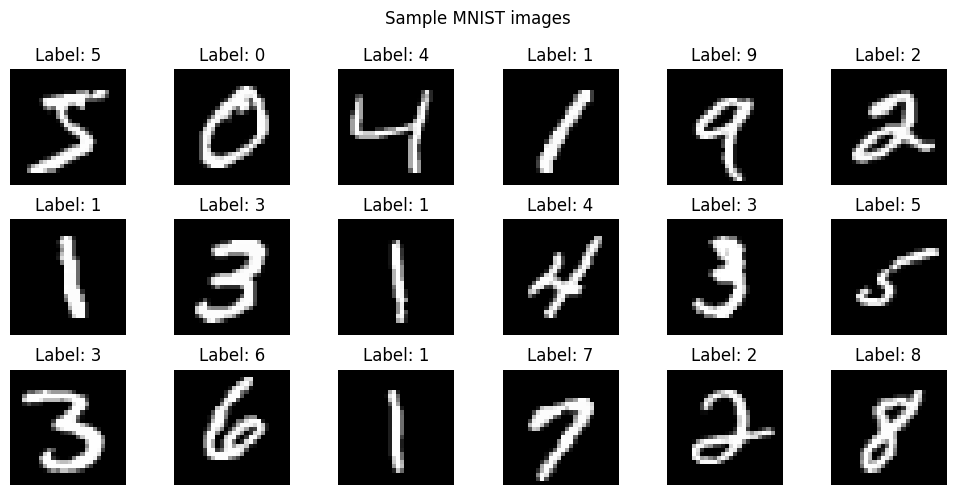

In [ ]:

fig, axes = plt.subplots(3, 6, figsize=(10, 5))
indices = list(range(18))

for ax, idx in zip(axes.flat, indices):
    ax.imshow(raw_train.data[idx], cmap="gray")
    ax.set_title(f"Label: {raw_train.targets[idx].item()}")
    ax.axis("off")

plt.suptitle("Sample MNIST images")
plt.tight_layout()
plt.show()


## 3. Custom `Dataset` + train / validation / test split

### 3.1 Define a custom dataset class

This follows the structure shown in the slides:

- `__init__(...)`
- `__len__(...)`
- `__getitem__(...)`

For speed, we normalize the image tensors once in the constructor.


In [ ]:

class MNISTTensorDataset(Dataset):
    """A simple custom Dataset that wraps MNIST image tensors and labels."""

    def __init__(self, images, labels, normalize=True):
        super().__init__()
        images = images.float()
        if normalize:
            images = images / 255.0
        self.images = images
        self.labels = labels.long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


In [ ]:

full_train_dataset = MNISTTensorDataset(raw_train.data, raw_train.targets, normalize=True)
full_test_dataset = MNISTTensorDataset(raw_test.data, raw_test.targets, normalize=True)

# create random number generator
generator = torch.Generator().manual_seed(SEED)

# Split the original training set into train + validation.
# In FAST_RUN mode, we also keep only a smaller subset to make Colab runs quick.
remainder_train = len(full_train_dataset) - TRAIN_SIZE - VAL_SIZE
if remainder_train < 0:
    raise ValueError("TRAIN_SIZE + VAL_SIZE is larger than the available MNIST training set.")

train_dataset, val_dataset, _ = random_split(
    full_train_dataset,
    [TRAIN_SIZE, VAL_SIZE, remainder_train],
    generator=generator
)

if TEST_SIZE < len(full_test_dataset):
    test_dataset, _ = random_split(
        full_test_dataset,
        [TEST_SIZE, len(full_test_dataset) - TEST_SIZE],
        generator=generator
    )
else:
    test_dataset = full_test_dataset

print(f"Train dataset size:      {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size:       {len(test_dataset)}")


Train dataset size:      12000
Validation dataset size: 2000
Test dataset size:       5000


### 3.2 Create `DataLoader` objects

This is the part that turns the dataset into **mini-batches**.


In [ ]:
# The object that turns the dataset into something you can iterate over in mini-batches during training


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"Number of train batches: {len(train_loader)}")
print(f"Number of val batches:   {len(val_loader)}")
print(f"Number of test batches:  {len(test_loader)}")


Number of train batches: 94
Number of val batches:   16
Number of test batches:  40


### 3.3 Inspect one batch

This connects directly to the slide idea of:

```python
for batch_x, batch_y in train_data_loader:
    ...
```


In [ ]:

batch_x, batch_y = next(iter(train_loader))
print(f"batch_x shape: {tuple(batch_x.shape)}")
print(f"batch_y shape: {tuple(batch_y.shape)}")
print(f"First 10 labels in the batch: {batch_y[:10].tolist()}")


batch_x shape: (128, 28, 28)
batch_y shape: (128,)
First 10 labels in the batch: [9, 0, 6, 5, 0, 3, 2, 3, 1, 4]


## 4. Define the MLP model

### 4.1 Model class

The original notebooks used a multilayer perceptron for MNIST.  
Here we keep the same idea: **flatten → linear → ReLU → linear → ReLU → output layer**.

> Important note: this notebook returns **raw logits** and uses **`CrossEntropyLoss`**.  
> That is the modern compact PyTorch equivalent of **`LogSoftmax + NLLLoss (Negative Log-Likelihood Loss)`**.


In [ ]:

class MLPNet(nn.Module):
    def __init__(self, hidden1=256, hidden2=128, n_classes=10):
        super().__init__()
        self.flatten = nn.Flatten() # reshapes the input from a multi-dimensional image into a single long vector
        self.fc1 = nn.Linear(28 * 28, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2, n_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)  # raw logits
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model_preview = MLPNet()
print(model_preview)
print(f"Trainable parameters: {count_parameters(model_preview):,}")


MLPNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)
Trainable parameters: 235,146


In [ ]:
# class MLPNetSequential(nn.Module):
#     def __init__(self, hidden1=256, hidden2=128, n_classes=10):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(28 * 28, hidden1),
#             nn.ReLU(),
#             nn.Linear(hidden1, hidden2),
#             nn.ReLU(),
#             nn.Linear(hidden2, n_classes)
#         )

#     def forward(self, x):
#         return self.net(x)


# def count_parameters(model):
#     return sum(p.numel() for p in model.parameters() if p.requires_grad)


# model_preview = MLPNetSequential()
# print(model_preview)
# print(f"Trainable parameters: {count_parameters(model_preview):,}")

### 4.2 Loss function and optimizer


In [ ]:

criterion = nn.CrossEntropyLoss()

def make_optimizer(model, optimizer_name=OPTIMIZER_NAME, lr=LEARNING_RATE):
    name = optimizer_name.lower()
    if name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr)
    if name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    raise ValueError("Unsupported optimizer name.")

optimizer_preview = make_optimizer(model_preview)
print(criterion)
print(optimizer_preview)


CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


### 4.3 One mini-batch update: the minimal training loop in action

This cell demonstrates **one** optimizer step on **one** batch:

1. forward pass  
2. compute loss  
3. backward pass  
4. optimizer step  
5. clear gradients before the next iteration


In [ ]:

demo_model = MLPNet().to(device)
demo_optimizer = make_optimizer(demo_model)

demo_x, demo_y = next(iter(train_loader))
demo_x = demo_x.to(device)
demo_y = demo_y.to(device)

demo_model.train()

with torch.no_grad():
    loss_before = criterion(demo_model(demo_x), demo_y).item()

demo_optimizer.zero_grad()
demo_logits = demo_model(demo_x)
demo_loss = criterion(demo_logits, demo_y)
demo_loss.backward()
demo_optimizer.step()

with torch.no_grad():
    loss_after = criterion(demo_model(demo_x), demo_y).item()

print(f"Loss before one update: {loss_before:.4f}")
print(f"Loss after one update:  {loss_after:.4f}")


Loss before one update: 2.2989
Loss after one update:  2.2517


## 5. Full training loop with validation and checkpoints

### 5.1 Helper functions

This section generalizes the minimal loop into reusable functions:

- `evaluate_model(...)`
- `train_model(...)`
- checkpoint save / resume


In [ ]:

def move_optimizer_to_device(optimizer, target_device):
    """Move optimizer state tensors to the same device as the model."""
    for state in optimizer.state.values():
        for key, value in state.items():
            if isinstance(value, torch.Tensor):
                state[key] = value.to(target_device)


def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_examples += x.size(0)

    return {
        "loss": total_loss / total_examples,
        "acc": total_correct / total_examples,
    }


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs,
    checkpoint_path=None,
    resume=False,
):
    start_epoch = 0
    history = []

    if resume and checkpoint_path is not None and Path(checkpoint_path).exists():
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        move_optimizer_to_device(optimizer, device)
        history = checkpoint.get("history", [])
        start_epoch = checkpoint["epoch"] + 1
        print(f"Resumed from checkpoint at epoch {start_epoch}.")

    model.to(device)

    for epoch in range(start_epoch, epochs):
        epoch_start = time.perf_counter()
        model.train()

        running_loss = 0.0
        running_correct = 0
        total_examples = 0

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            total_examples += x.size(0)

        train_loss = running_loss / total_examples
        train_acc = running_correct / total_examples
        val_metrics = evaluate_model(model, val_loader, criterion, device)

        row = {
            "epoch": epoch + 1,
            "train_loss": float(train_loss),
            "train_acc": float(train_acc),
            "val_loss": float(val_metrics["loss"]),
            "val_acc": float(val_metrics["acc"]),
            "seconds": float(time.perf_counter() - epoch_start),
        }
        history.append(row)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"train_loss={row['train_loss']:.4f} | "
            f"train_acc={row['train_acc']:.4f} | "
            f"val_loss={row['val_loss']:.4f} | "
            f"val_acc={row['val_acc']:.4f} | "
            f"time={row['seconds']:.1f}s"
        )

        if checkpoint_path is not None:
            payload = {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "history": history,
                "config": {
                    "optimizer_name": OPTIMIZER_NAME,
                    "learning_rate": LEARNING_RATE,
                    "batch_size": BATCH_SIZE,
                    "fast_run": FAST_RUN,
                },
            }
            torch.save(payload, checkpoint_path)

    return model, history


def plot_history(history):
    epochs = [row["epoch"] for row in history]

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, [row["train_loss"] for row in history], marker="o", label="train loss")
    plt.plot(epochs, [row["val_loss"] for row in history], marker="o", label="validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, [row["train_acc"] for row in history], marker="o", label="train accuracy")
    plt.plot(epochs, [row["val_acc"] for row in history], marker="o", label="validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and validation accuracy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def show_predictions(model, data_loader, device, n=16):
    model.eval()
    images, labels = next(iter(data_loader))
    images_device = images.to(device)

    with torch.no_grad():
        preds = model(images_device).argmax(dim=1).cpu()

    n = min(n, len(images))
    rows = int((n + 3) / 4)
    plt.figure(figsize=(10, 2.4 * rows))

    for i in range(n):
        plt.subplot(rows, 4, i + 1)
        plt.imshow(images[i], cmap="gray")
        correct = preds[i].item() == labels[i].item()
        title_color = "green" if correct else "red"
        plt.title(f"T={labels[i].item()} | P={preds[i].item()}", color=title_color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


### 5.2 Stage 1: train for a few epochs and save checkpoints

This demonstrates the checkpoint idea from the slides:
the training loop state is saved after each epoch.


In [ ]:

if CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH.unlink()
    print(f"Removed old checkpoint: {CHECKPOINT_PATH}")
else:
    print("No old checkpoint found.")


No old checkpoint found.


In [ ]:

model_stage1 = MLPNet()
optimizer_stage1 = make_optimizer(model_stage1)

model_stage1, history_stage1 = train_model(
    model=model_stage1,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_stage1,
    criterion=criterion,
    device=device,
    epochs=FIRST_STAGE_EPOCHS,
    checkpoint_path=CHECKPOINT_PATH,
    resume=False,
)

print(f"Checkpoint exists after stage 1: {CHECKPOINT_PATH.exists()}")


Epoch 01/2 | train_loss=0.7589 | train_acc=0.7970 | val_loss=0.3519 | val_acc=0.9020 | time=1.6s
Epoch 02/2 | train_loss=0.2992 | train_acc=0.9106 | val_loss=0.2715 | val_acc=0.9250 | time=1.4s
Checkpoint exists after stage 1: True


### 5.3 Stage 2: create a fresh model, load the checkpoint, and continue training

This simulates what happens if a training session stops and you want to continue later.


In [ ]:

model = MLPNet()
optimizer = make_optimizer(model)

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=TOTAL_EPOCHS,
    checkpoint_path=CHECKPOINT_PATH,
    resume=True,
)


Resumed from checkpoint at epoch 2.
Epoch 03/4 | train_loss=0.2219 | train_acc=0.9344 | val_loss=0.2335 | val_acc=0.9365 | time=1.1s
Epoch 04/4 | train_loss=0.1827 | train_acc=0.9464 | val_loss=0.2064 | val_acc=0.9445 | time=1.2s


## 6. Evaluate the final model

### 6.1 Plot train / validation history


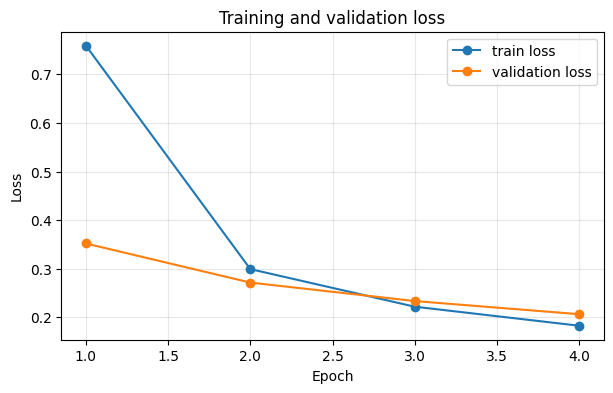

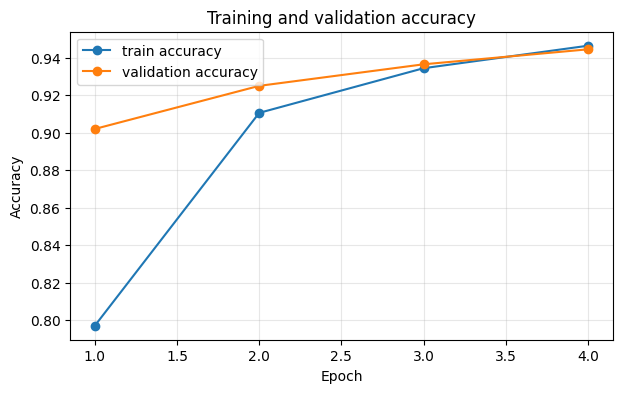

In [ ]:

plot_history(history)


### 6.2 Final test-set performance


In [ ]:

test_metrics = evaluate_model(model, test_loader, criterion, device)
print(
    f"Test loss: {test_metrics['loss']:.4f} | "
    f"Test accuracy: {test_metrics['acc']:.4f}"
)


Test loss: 0.2014 | Test accuracy: 0.9422


### 6.3 Inspect a few predictions


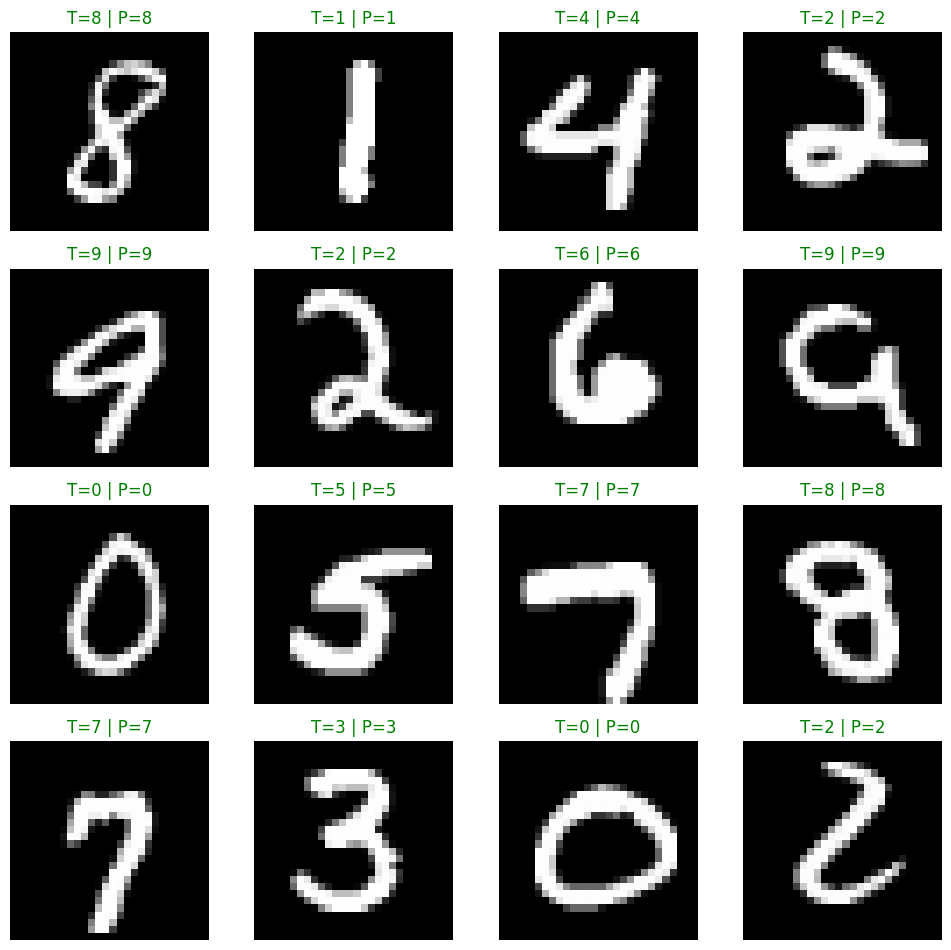

In [ ]:

show_predictions(model, test_loader, device, n=16)


## 7. Key takeaways

- **Dataset** objects define how samples are stored and accessed.
- **DataLoader** objects turn datasets into shuffled mini-batches.
- The **minimal training loop** is: forward → loss → backward → optimizer step.
- A **validation set** lets you monitor generalization during training.
- **Checkpoints** save the model weights, optimizer state, epoch number, and training history.
- For modern PyTorch classification, **raw logits + `CrossEntropyLoss`** is usually the cleanest setup.

You can now extend this notebook with:

- larger / deeper MLPs
- dropout
- SGD vs Adam comparisons
- confusion matrices
- CNNs for stronger MNIST performance
